# Online Retail II — Exploratory Data Analysis

**Dataset:** [Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) (UCI Machine Learning Repository)

This notebook explores transactional sales data from a UK-based online gift retailer, covering
**01 Dec 2009 – 09 Dec 2011**. The goal is to understand the data, surface potential business
problems, and frame a suitable machine learning approach — see `README.md` for the full write-up.


## 1. Load the data

The source file is an Excel workbook with two sheets, one per year. We load and combine both.

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

xls_path = "online_retail_II.xlsx"  # place the downloaded file alongside this notebook

sheet_2009_2010 = pd.read_excel(xls_path, sheet_name="Year 2009-2010")
sheet_2010_2011 = pd.read_excel(xls_path, sheet_name="Year 2010-2011")

df = pd.concat([sheet_2009_2010, sheet_2010_2011], ignore_index=True)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Dataset shape

In [2]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.shape

Rows: 1,067,371
Columns: 8


(1067371, 8)

## 3. Data types

In [3]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

## 4. Column overview

| Column | Meaning |
|---|---|
| `Invoice` | Invoice number. Invoices starting with **C** are cancellations. |
| `StockCode` | Product (item) code. |
| `Description` | Product name. |
| `Quantity` | Units sold per line item (negative = return/cancellation). |
| `InvoiceDate` | Date and time the invoice was generated. |
| `Price` | Unit price in GBP (£). |
| `Customer ID` | Unique customer identifier (missing for guest/unregistered orders). |
| `Country` | Customer's country. |


## 5. Missing values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


`Customer ID` is missing for roughly 23% of rows — these are effectively unattributable (guest) transactions. `Description` has a small number of missing values, likely data-entry gaps for discontinued or adjustment codes.

## 6. Summary statistics

In [5]:
df.describe(include='number')

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [6]:
df.describe(include=['object', 'str', 'datetime'])

,Invoice,StockCode,Description,InvoiceDate,Country
count,1067371.0,1067371,1062989,1067371,1067371
unique,53628.0,5305,5698,NaN,43
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,United Kingdom
freq,1350.0,5829,5918,NaN,981330
mean,NaN,NaN,NaN,2011-01-02 21:13:55.394029,NaN
min,NaN,NaN,NaN,2009-12-01 07:45:00,NaN
25%,NaN,NaN,NaN,2010-07-09 09:46:00,NaN
50%,NaN,NaN,NaN,2010-12-07 15:28:00,NaN
75%,NaN,NaN,NaN,2011-07-22 10:23:00,NaN
max,NaN,NaN,NaN,2011-12-09 12:50:00,NaN


## 7. Data quality checks

The `Quantity` and `Price` columns contain negative values, and some invoices are cancellations
(`Invoice` starting with `"C"`). These need to be understood before any modeling.

In [7]:
df['IsCancelled'] = df['Invoice'].astype(str).str.startswith('C')

print(f"Cancelled invoice line items: {df['IsCancelled'].sum():,} ({df['IsCancelled'].mean()*100:.2f}% of rows)")
print(f"Rows with negative Quantity:   {(df['Quantity'] < 0).sum():,}")
print(f"Rows with negative Price:      {(df['Price'] < 0).sum():,}")
print(f"Rows with zero Price:          {(df['Price'] == 0).sum():,}")

Cancelled invoice line items: 19,494 (1.83% of rows)
Rows with negative Quantity:   22,950
Rows with negative Price:      5
Rows with zero Price:          6,202


In [8]:
print(f"Unique invoices:   {df['Invoice'].nunique():,}")
print(f"Unique products:   {df['StockCode'].nunique():,}")
print(f"Unique customers:  {df['Customer ID'].nunique():,}")
print(f"Unique countries:  {df['Country'].nunique()}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

Unique invoices:   53,628
Unique products:   5,305
Unique customers:  5,942
Unique countries:  43
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


## 8. Country distribution

Where are orders coming from?

In [9]:
df['Country'].value_counts().head(10)

Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64

## 9. Building a clean transaction table

For any revenue-based analysis we exclude cancellations and non-positive quantity/price rows, then derive a `Revenue` field.

In [10]:
clean = df[
    (~df['IsCancelled']) &
    (df['Quantity'] > 0) &
    (df['Price'] > 0)
].copy()

clean['Revenue'] = clean['Quantity'] * clean['Price']

print(f"Clean rows: {clean.shape[0]:,} ({clean.shape[0]/df.shape[0]*100:.1f}% of original)")
print(f"Total revenue in clean data: £{clean['Revenue'].sum():,.2f}")

Clean rows: 1,041,670 (97.6% of original)
Total revenue in clean data: £20,972,594.57


## 10. Monthly revenue trend

In [11]:
clean['YearMonth'] = clean['InvoiceDate'].dt.to_period('M')
monthly_revenue = clean.groupby('YearMonth')['Revenue'].sum()
monthly_revenue

YearMonth
2009-12     825685.760
2010-01     652708.502
2010-02     553339.736
2010-03     833570.131
2010-04     681528.992
2010-05     659858.860
2010-06     752270.140
2010-07     650712.940
2010-08     697274.910
2010-09     924333.011
2010-10    1165483.910
2010-11    1470272.482
2010-12    1262598.790
2011-01     691364.560
2011-02     523631.890
2011-03     717639.360
2011-04     537808.621
2011-05     770536.020
2011-06     761739.900
2011-07     719221.191
2011-08     759138.380
2011-09    1058590.172
2011-10    1154979.300
2011-11    1509496.330
2011-12     638810.680
Freq: M, Name: Revenue, dtype: float64

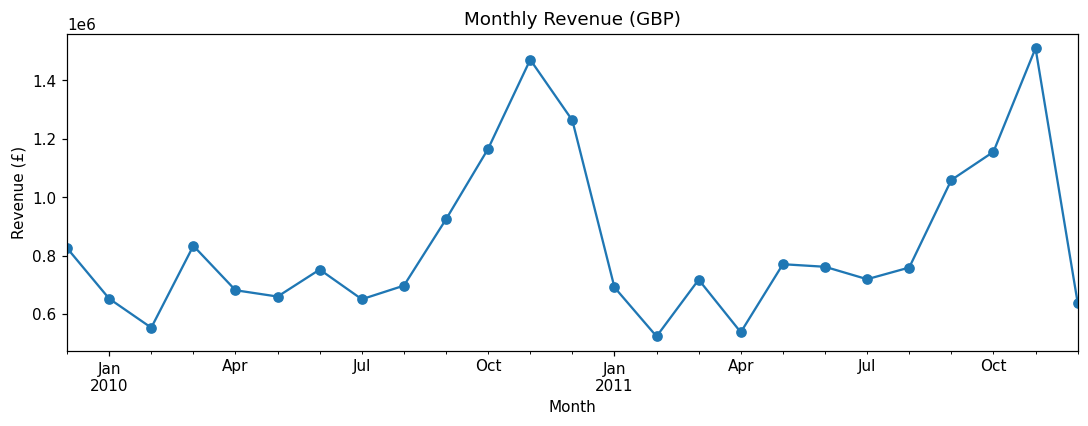

In [12]:
import matplotlib.pyplot as plt

ax = monthly_revenue.plot(kind='line', marker='o', figsize=(10, 4), title='Monthly Revenue (GBP)')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

There is a clear **seasonal peak in Sep–Nov** each year (build-up to Christmas gift buying), consistent with the retailer's gift-focused product catalogue.

## 11. Building a customer-level (RFM) view

Many of the business problems below (segmentation, churn) are naturally framed at the
**customer** level rather than the transaction level. We construct Recency, Frequency, and
Monetary (RFM) features per customer, which will double as the feature set for a clustering
or churn model.

In [13]:
customer_df = clean.dropna(subset=['Customer ID']).copy()
snapshot_date = customer_df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = customer_df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,3018.616737
std,1715.572666,209.338707,13.009406,14737.731040
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,348.762500
50%,15314.500000,96.000000,3.000000,898.915000
75%,16797.750000,380.000000,7.000000,2307.090000
max,18287.000000,739.000000,398.000000,608821.650000


In [14]:
rfm.head(10)

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40
5,12351.0,375,1,300.93
6,12352.0,36,10,2849.84
7,12353.0,204,2,406.76
8,12354.0,232,1,1079.40
9,12355.0,214,2,947.61


## 12. Three key observations

1. **~23% of transaction rows have no `Customer ID`.** These are guest/unattributed orders and
   cannot be tied to a specific customer, which limits customer-level modeling (RFM, churn,
   CLV) to the ~77% of rows that do carry an ID — any such model will need to explicitly state
   this coverage limitation.
2. **Revenue is strongly seasonal**, peaking every September–November before Christmas and
   dropping sharply afterward — a pattern that should inform both demand forecasting and how
   "churn" is defined (a slow month in summer isn't necessarily churn).
3. **Cancellations and returns are non-trivial**, with negative `Quantity` on roughly 2% of
   invoices and 22,950 rows in total. These must be filtered out (or modeled separately) before
   computing revenue, RFM features, or any target variable — otherwise metrics like customer
   `Monetary` value get distorted.


---

See `README.md` in this repository for the full business-problem framing, ML problem selection, and target variable / feature discussion.